# Online Retail Sales & Customer Analytics

## Data Analytics Capstone Project

**Dataset:** UCI Online Retail  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Power BI, Git & GitHub

### Project Objective
Analyze online retail transaction data to understand sales performance, product demand,
customer behavior, geographical markets, purchasing patterns, and opportunities for
business improvement.

> **Notebook workflow:** Task 3 covers data inspection, cleaning and preparation. Task 4
> covers exploratory data analysis (EDA). The cleaned dataset created in Task 3 is reused
> throughout the EDA.

# Task 3 — Dataset Selection & Data Preparation

## 3.1 Import Libraries

The notebook uses Pandas and NumPy for data handling and Matplotlib/Seaborn for analysis
and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3.2 Load the Raw Dataset

In [2]:
file_path = "../Data/Raw/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3.3 Initial Data Inspection

In [3]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Last 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France



Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


## 3.4 Missing-Value Analysis

In [4]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
}).sort_values('Missing Values', ascending=False)

missing_summary

,Missing Values,Missing Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


## 3.5 Duplicate and Invalid-Record Checks

In [5]:
duplicate_count = df.duplicated().sum()
quantity_invalid = (df['Quantity'] <= 0).sum()
price_invalid = (df['UnitPrice'] <= 0).sum()
cancelled_count = df['InvoiceNo'].astype(str).str.startswith('C').sum()

print("Duplicate rows:", duplicate_count)
print("Quantity <= 0:", quantity_invalid)
print("UnitPrice <= 0:", price_invalid)
print("Cancelled transaction rows:", cancelled_count)

Duplicate rows: 5268
Quantity <= 0: 10624
UnitPrice <= 0: 2517
Cancelled transaction rows: 9288


## 3.6 Inspect Problematic Records

In [6]:
print("Sample records with Quantity <= 0:")
display(df[df['Quantity'] <= 0].head(10))

print("\nSample records with UnitPrice <= 0:")
display(df[df['UnitPrice'] <= 0].head(10))

print("\nSample cancelled transactions:")
cancelled = df['InvoiceNo'].astype(str).str.startswith('C')
display(df[cancelled].head(10))

Sample records with Quantity <= 0:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom



Sample records with UnitPrice <= 0:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom



Sample cancelled transactions:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


## 3.7 Data Cleaning

The following rules are applied to prepare a transaction-level sales dataset:

- Remove duplicate rows.
- Remove records with missing product descriptions.
- Remove cancelled invoices.
- Keep only positive quantities.
- Keep only positive unit prices.
- Retain missing CustomerID values for non-customer-level analysis.

In [7]:
df = df.drop_duplicates()

df = df.dropna(subset=['Description'])

df = df[
    ~df['InvoiceNo'].astype(str).str.startswith('C')
]

df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

print("Rows after cleaning:", len(df))

Rows after cleaning: 524878


## 3.8 Feature Engineering

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['SalesAmount'] = df['Quantity'] * df['UnitPrice']

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.strftime('%B')
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount,Year,Month,MonthName,Day,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8


## 3.9 Final Data-Quality Check

In [9]:
print("FINAL DATASET CHECK")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nMinimum Quantity:", df['Quantity'].min())
print("Minimum Unit Price:", df['UnitPrice'].min())

print("\nDate Range:")
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

print("\nUnique Products:", df['StockCode'].nunique())
print("Unique Countries:", df['Country'].nunique())
print("Unique Customers:", df['CustomerID'].nunique())

print("\nTotal Sales Amount:")
print(df['SalesAmount'].sum())

FINAL DATASET CHECK
Rows: 524878
Columns: 15

Missing Values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
SalesAmount         0
Year                0
Month               0
MonthName           0
Day                 0
DayOfWeek           0
Hour                0
dtype: int64

Duplicate Rows: 0

Minimum Quantity: 1
Minimum Unit Price: 0.001

Date Range:
2010-12-01 08:26:00
2011-12-09 12:50:00

Unique Products: 3922
Unique Countries: 38
Unique Customers: 4338

Total Sales Amount:
10642110.804000001


## 3.10 Save the Processed Dataset

In [10]:
output_excel = "../Data/Processed/Online_Retail_Cleaned.xlsx"
output_csv = "../Data/Processed/Online_Retail_Cleaned.csv"

df.to_excel(output_excel, index=False)
df.to_csv(output_csv, index=False)

print("Cleaned Excel file saved successfully.")
print("Cleaned CSV file saved successfully.")

Cleaned Excel file saved successfully.
Cleaned CSV file saved successfully.


# Task 4 — Exploratory Data Analysis (EDA)

## EDA Objective
Explore the cleaned dataset to identify descriptive statistics, business metrics,
sales trends, product and country performance, customer behavior, correlations,
outliers, and actionable patterns.

## 4.1 Basic Dataset Inspection

In [11]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

Dataset shape: (524878, 15)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount,Year,Month,MonthName,Day,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8



Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
SalesAmount           float64
Year                    int32
Month                   int32
MonthName                 str
Day                     int32
DayOfWeek                 str
Hour                    int32
dtype: object


## 4.2 Descriptive Statistics

In [12]:
df[['Quantity', 'UnitPrice', 'SalesAmount']].describe()

,Quantity,UnitPrice,SalesAmount
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


## 4.3 Overall Business Metrics

In [13]:
total_sales = df['SalesAmount'].sum()
total_orders = df['InvoiceNo'].nunique()
total_units = df['Quantity'].sum()
total_products = df['StockCode'].nunique()
total_customers = df['CustomerID'].nunique()
total_countries = df['Country'].nunique()

average_order_value = total_sales / total_orders

print("Total Sales: £", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Units Sold:", total_units)
print("Unique Products:", total_products)
print("Unique Customers:", total_customers)
print("Countries:", total_countries)
print("Average Order Value: £", round(average_order_value, 2))

Total Sales: £ 10642110.8
Total Orders: 19960
Total Units Sold: 5572420
Unique Products: 3922
Unique Customers: 4338
Countries: 38
Average Order Value: £ 533.17


## 4.4 Missing-Value Verification

In [14]:
missing_after_cleaning = df.isnull().sum()

print(missing_after_cleaning)

missing_customer_count = df['CustomerID'].isnull().sum()
missing_customer_percentage = (missing_customer_count / len(df)) * 100

print("\nMissing CustomerID:", missing_customer_count)
print("Missing CustomerID Percentage:", round(missing_customer_percentage, 2), "%")

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
SalesAmount         0
Year                0
Month               0
MonthName           0
Day                 0
DayOfWeek           0
Hour                0
dtype: int64

Missing CustomerID: 132186
Missing CustomerID Percentage: 25.18 %


### Interpretation
Missing CustomerID values are retained because the associated transactions remain valid
for sales, product, country and time analysis. Customer-level analysis will use records
with a valid CustomerID.

## 4.5 Monthly Sales Trend

In [15]:
monthly_sales = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))['SalesAmount']
    .sum()
    .reset_index()
)

monthly_sales['InvoiceDate'] = monthly_sales['InvoiceDate'].astype(str)

display(monthly_sales)

,InvoiceDate,SalesAmount
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


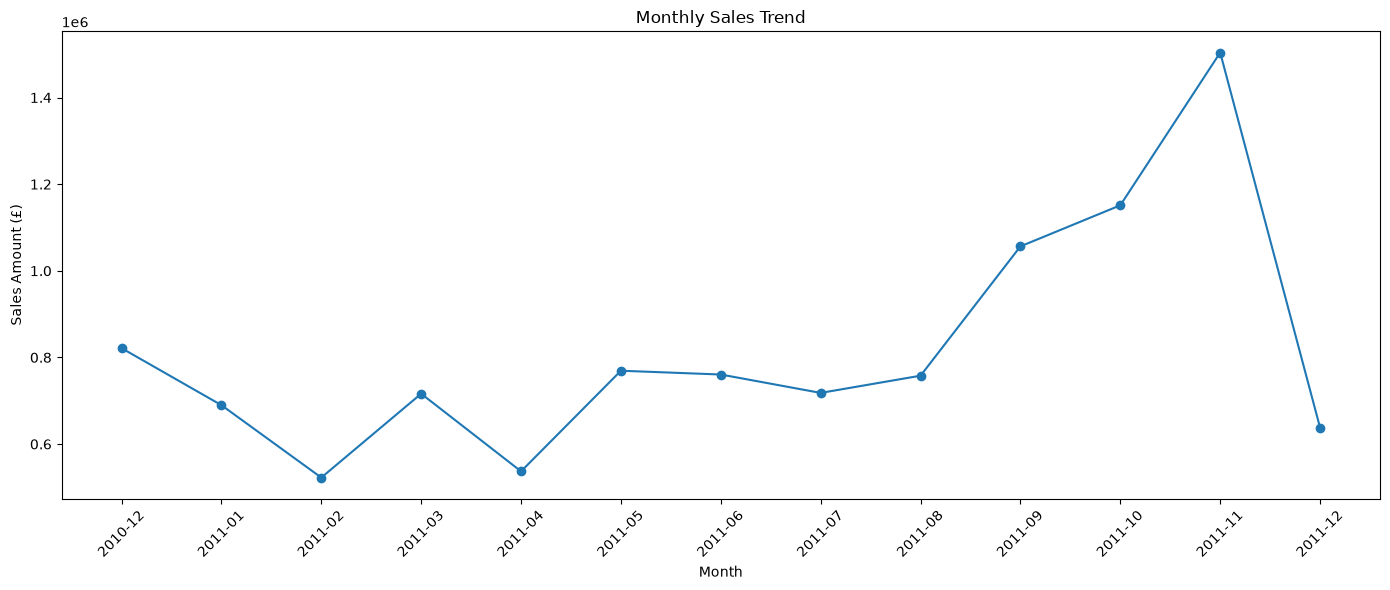

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['InvoiceDate'],
    monthly_sales['SalesAmount'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Amount (£)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    "../visualizations/monthly_sales_trend.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 4.6 Country Sales Analysis

In [17]:
country_sales = (
    df.groupby('Country')['SalesAmount']
    .sum()
    .sort_values(ascending=False)
)

display(country_sales.head(10))

uk_sales = df.loc[
    df['Country'] == 'United Kingdom',
    'SalesAmount'
].sum()

uk_share = (uk_sales / total_sales) * 100

print("United Kingdom Sales: £", round(uk_sales, 2))
print("United Kingdom Sales Share:", round(uk_share, 2), "%")

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: SalesAmount, dtype: float64

United Kingdom Sales: £ 9001744.09
United Kingdom Sales Share: 84.59 %


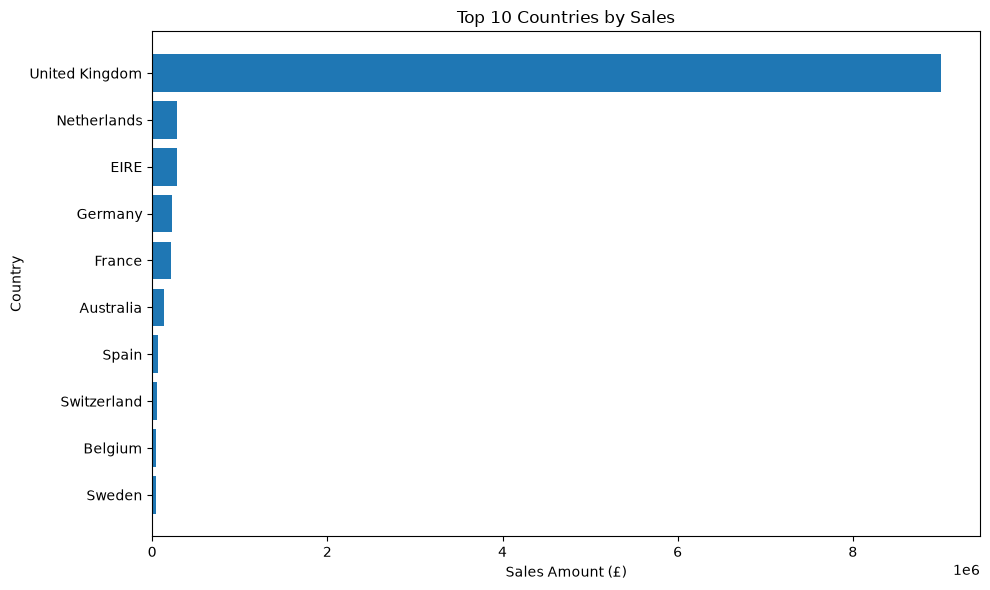

In [18]:
top_countries = country_sales.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries.index,
    top_countries.values
)

plt.title('Top 10 Countries by Sales')
plt.xlabel('Sales Amount (£)')
plt.ylabel('Country')

plt.tight_layout()
plt.savefig(
    "../visualizations/top_countries_sales.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 4.7 Product Sales Analysis

In [19]:
product_sales = (
    df.groupby('Description')
    .agg(
        Sales=('SalesAmount', 'sum'),
        Units=('Quantity', 'sum'),
        Orders=('InvoiceNo', 'nunique')
    )
    .sort_values(by='Sales', ascending=False)
)

display(product_sales.head(10))

,Sales,Units,Orders
Description,,,
DOTCOM POSTAGE,206248.77,706,706
REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
WHITE HANGING HEART T-LIGHT HOLDER,106236.72,37872,2256
PARTY BUNTING,99445.23,18283,1685
JUMBO BAG RED RETROSPOT,94159.81,48371,2089
MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
POSTAGE,78101.88,3150,1126
Manual,77752.82,6985,290


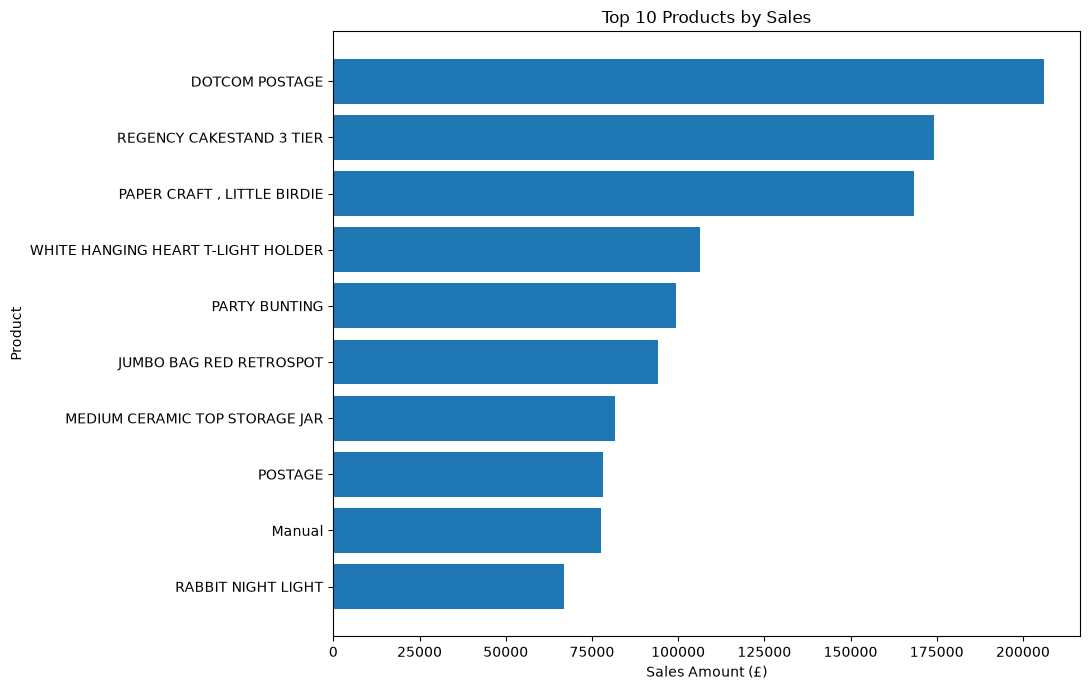

In [20]:
top_products = product_sales.head(10).sort_values('Sales')

plt.figure(figsize=(11, 7))

plt.barh(
    top_products.index,
    top_products['Sales']
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales Amount (£)')
plt.ylabel('Product')

plt.tight_layout()
plt.savefig(
    "../visualizations/top_products_sales.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 4.8 Sales by Day of Week

In [21]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_sales = (
    df.groupby('DayOfWeek')['SalesAmount']
    .sum()
    .reindex(day_order)
)

display(day_sales)

DayOfWeek
Monday       1775782.071
Tuesday      2175700.511
Wednesday    1847074.380
Thursday     2199292.570
Friday       1837470.491
Saturday             NaN
Sunday        806790.781
Name: SalesAmount, dtype: float64

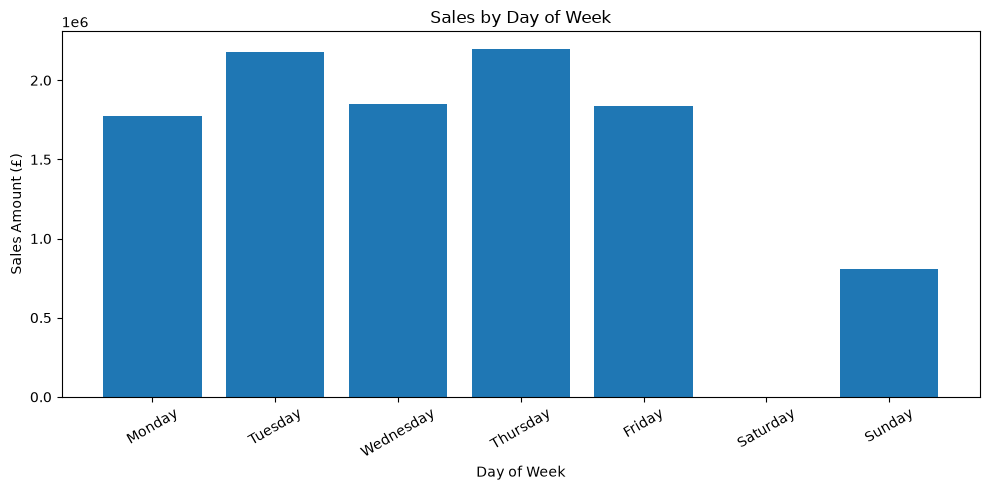

In [22]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_sales.index,
    day_sales.values
)

plt.title('Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Sales Amount (£)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(
    "../visualizations/sales_by_day.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 4.9 Sales by Hour

In [23]:
hour_sales = df.groupby('Hour')['SalesAmount'].sum()

display(hour_sales)

Hour
6           4.250
7       31059.210
8      283750.680
9      990054.991
10    1444814.771
11    1236573.290
12    1439324.660
13    1261195.200
14    1177907.521
15    1350333.310
16     752487.960
17     460963.921
18     144603.610
19      50204.950
20      18832.480
Name: SalesAmount, dtype: float64

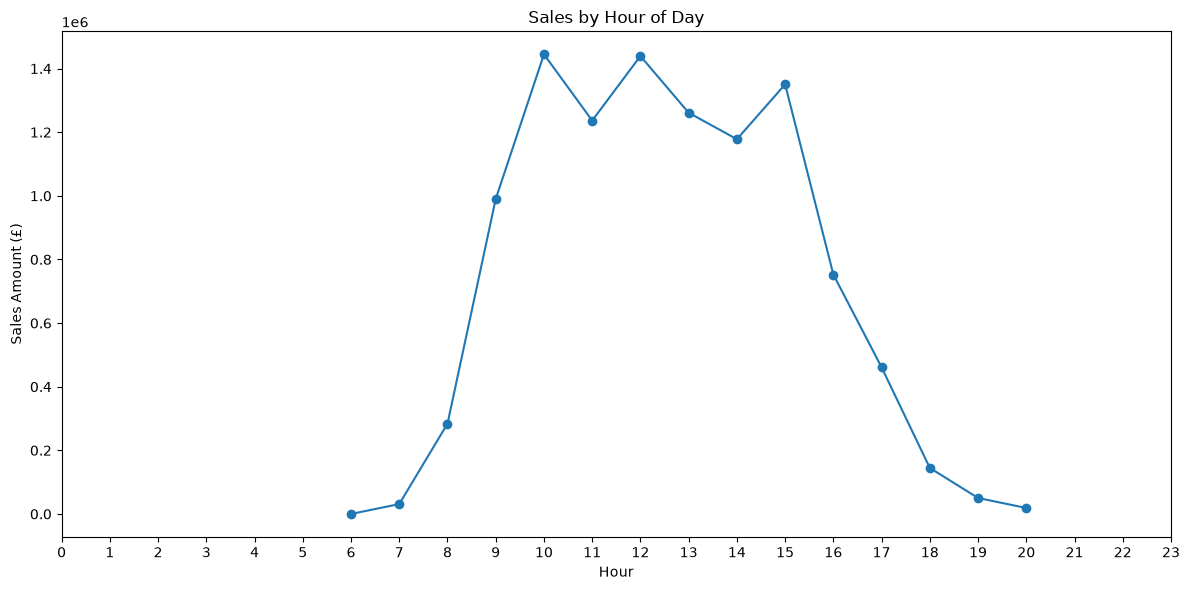

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    hour_sales.index,
    hour_sales.values,
    marker='o'
)

plt.title('Sales by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Sales Amount (£)')
plt.xticks(range(0, 24))

plt.tight_layout()
plt.savefig(
    "../visualizations/sales_by_hour.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 4.10 Correlation Analysis

In [25]:
numeric_columns = [
    'Quantity',
    'UnitPrice',
    'SalesAmount',
    'Year',
    'Month',
    'Day',
    'Hour'
]

correlation_matrix = df[numeric_columns].corr()

display(correlation_matrix)

,Quantity,UnitPrice,SalesAmount,Year,Month,Day,Hour
Quantity,1.000000,-0.003788,0.907402,0.003506,-0.002212,-0.000926,-0.018851
UnitPrice,-0.003788,1.000000,0.137381,-0.007447,0.000372,-0.000509,0.004383
SalesAmount,0.907402,0.137381,1.000000,0.000252,0.000465,-0.001834,-0.015683
Year,0.003506,-0.007447,0.000252,1.000000,-0.369007,0.163531,-0.011173
Month,-0.002212,0.000372,0.000465,-0.369007,1.000000,-0.117457,0.027224
Day,-0.000926,-0.000509,-0.001834,0.163531,-0.117457,1.000000,0.000078
Hour,-0.018851,0.004383,-0.015683,-0.011173,0.027224,0.000078,1.000000


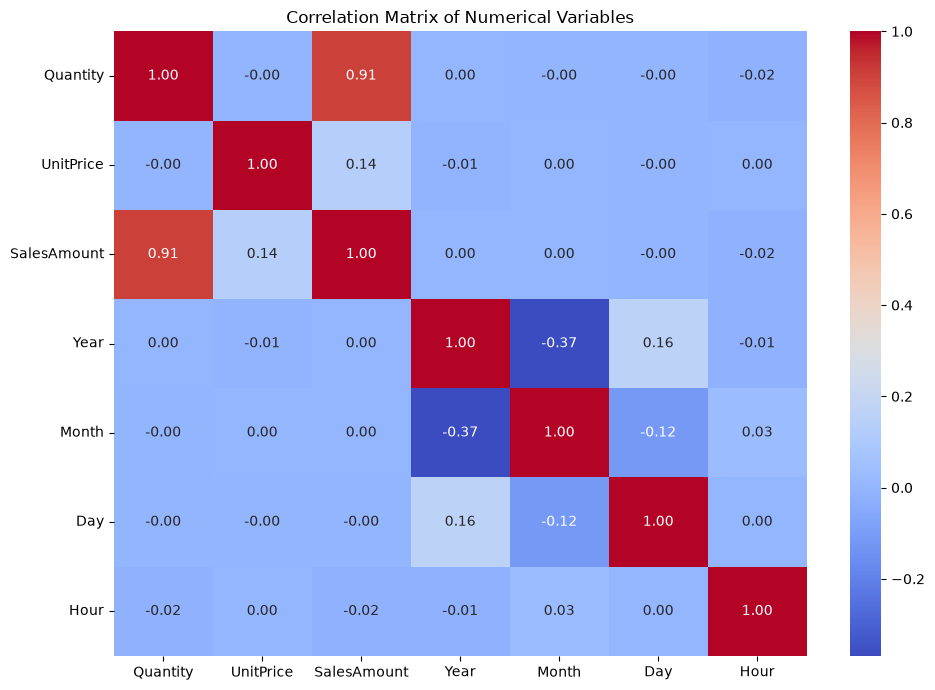

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.savefig(
    "../visualizations/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 4.11 Outlier Analysis — Quantity

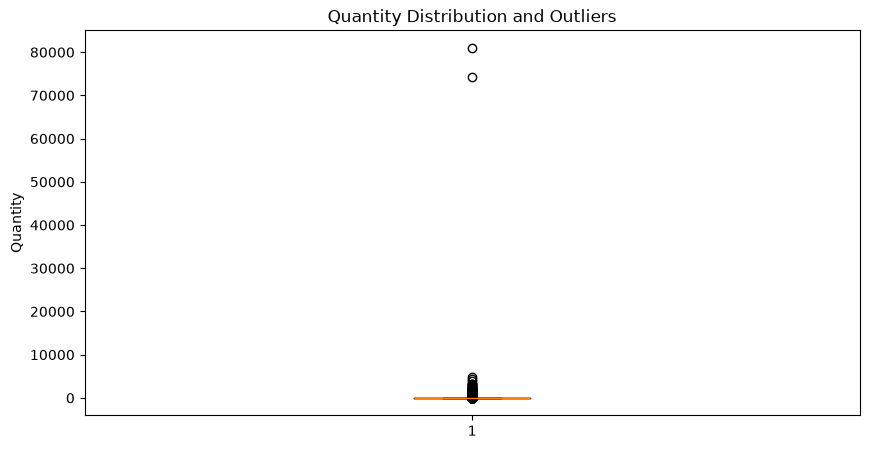

In [27]:
plt.figure(figsize=(10, 5))

plt.boxplot(df['Quantity'])

plt.title('Quantity Distribution and Outliers')
plt.ylabel('Quantity')

plt.show()

In [28]:
Q1_quantity = df['Quantity'].quantile(0.25)
Q3_quantity = df['Quantity'].quantile(0.75)
IQR_quantity = Q3_quantity - Q1_quantity

lower_quantity = Q1_quantity - 1.5 * IQR_quantity
upper_quantity = Q3_quantity + 1.5 * IQR_quantity

quantity_outliers = df[
    (df['Quantity'] < lower_quantity) |
    (df['Quantity'] > upper_quantity)
]

print("Q1:", Q1_quantity)
print("Q3:", Q3_quantity)
print("IQR:", IQR_quantity)
print("Lower Bound:", lower_quantity)
print("Upper Bound:", upper_quantity)
print("Number of Quantity Outliers:", len(quantity_outliers))

Q1: 1.0
Q3: 11.0
IQR: 10.0
Lower Bound: -14.0
Upper Bound: 26.0
Number of Quantity Outliers: 27111


## 4.12 Outlier Analysis — Sales Amount

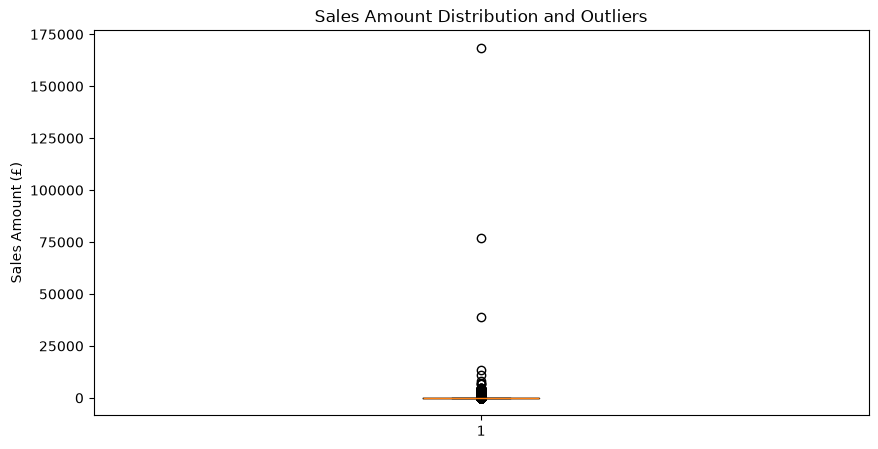

In [29]:
plt.figure(figsize=(10, 5))

plt.boxplot(df['SalesAmount'])

plt.title('Sales Amount Distribution and Outliers')
plt.ylabel('Sales Amount (£)')

plt.show()

In [30]:
Q1_sales = df['SalesAmount'].quantile(0.25)
Q3_sales = df['SalesAmount'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales

lower_sales = Q1_sales - 1.5 * IQR_sales
upper_sales = Q3_sales + 1.5 * IQR_sales

sales_outliers = df[
    (df['SalesAmount'] < lower_sales) |
    (df['SalesAmount'] > upper_sales)
]

print("Q1:", Q1_sales)
print("Q3:", Q3_sales)
print("IQR:", IQR_sales)
print("Lower Bound:", lower_sales)
print("Upper Bound:", upper_sales)
print("Number of SalesAmount Outliers:", len(sales_outliers))

Q1: 3.9
Q3: 17.700000000000003
IQR: 13.800000000000002
Lower Bound: -16.800000000000004
Upper Bound: 38.400000000000006
Number of SalesAmount Outliers: 42624


## 4.13 Investigate Extreme Transactions

In [31]:
largest_transactions = (
    df[
        [
            'InvoiceNo',
            'StockCode',
            'Description',
            'Quantity',
            'UnitPrice',
            'SalesAmount',
            'Country'
        ]
    ]
    .sort_values(by='SalesAmount', ascending=False)
)

display(largest_transactions.head(20))

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,SalesAmount,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,United Kingdom
173382,551697,POST,POSTAGE,1,8142.75,8142.75,United Kingdom
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,Netherlands


In [32]:
largest_quantities = (
    df[
        [
            'InvoiceNo',
            'StockCode',
            'Description',
            'Quantity',
            'UnitPrice',
            'SalesAmount'
        ]
    ]
    .sort_values(by='Quantity', ascending=False)
)

display(largest_quantities.head(20))

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,SalesAmount
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40


### Outlier Interpretation
Outliers are investigated rather than automatically removed. Large transactions may
represent legitimate bulk purchases or high-value orders, so deleting them would risk
removing commercially meaningful information.

## 4.14 Customer Analysis

In [33]:
customer_df = df.dropna(subset=['CustomerID']).copy()

print("Customer-level records:", len(customer_df))
print("Identified customers:", customer_df['CustomerID'].nunique())

Customer-level records: 392692
Identified customers: 4338


In [34]:
customer_sales = (
    customer_df
    .groupby('CustomerID')['SalesAmount']
    .sum()
    .sort_values(ascending=False)
)

customer_orders = (
    customer_df
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

customer_summary = pd.DataFrame({
    'Total Sales': customer_sales,
    'Total Orders': customer_orders
})

customer_summary['Average Order Value'] = (
    customer_summary['Total Sales'] /
    customer_summary['Total Orders']
)

display(customer_summary.head(10))

,Total Sales,Total Orders,Average Order Value
CustomerID,,,
12346.0,77183.60,1,77183.600000
12347.0,4310.00,7,615.714286
12348.0,1797.24,4,449.310000
12349.0,1757.55,1,1757.550000
12350.0,334.40,1,334.400000
12352.0,2506.04,8,313.255000
12353.0,89.00,1,89.000000
12354.0,1079.40,1,1079.400000
12355.0,459.40,1,459.400000


## 4.15 EDA Summary

In [35]:
eda_summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Orders',
        'Total Units Sold',
        'Unique Customers',
        'Unique Products',
        'Countries',
        'Average Order Value',
        'UK Sales Share'
    ],
    'Value': [
        round(total_sales, 2),
        total_orders,
        total_units,
        total_customers,
        total_products,
        total_countries,
        round(average_order_value, 2),
        round(uk_share, 2)
    ]
})

display(eda_summary)

,Metric,Value
0,Total Sales,10642110.80
1,Total Orders,19960.00
2,Total Units Sold,5572420.00
3,Unique Customers,4338.00
4,Unique Products,3922.00
5,Countries,38.00
6,Average Order Value,533.17
7,UK Sales Share,84.59


# Key EDA Findings

### 1. Overall Sales Performance
The cleaned dataset generated approximately £10.64 million in sales across 19,960 unique
invoices, with an average order value of approximately £533.17.

### 2. Dominant Market
The United Kingdom contributes approximately 84.59% of total sales, making it the
dominant market.

### 3. Sales Growth and Seasonality
Sales increase strongly during 2011, with November recording the highest monthly sales
and indicating strong year-end demand.

### 4. Product Performance
A relatively small group of products contributes a significant amount of sales, with
gift, household and decorative products appearing prominently among top-selling items.

### 5. Quantity and Revenue Relationship
Quantity has a strong positive correlation with SalesAmount, indicating that transaction
revenue is strongly associated with the number of units purchased.

### 6. Customer Data Availability
Approximately 25.18% of cleaned transactions have no CustomerID. These transactions
remain useful for overall sales and product analysis but cannot be reliably assigned to
individual customers.

### 7. Purchase Timing
Sales are concentrated in daytime hours, while Tuesday and Thursday are among the
stronger sales days.

### 8. Outliers
The dataset contains significant outliers in quantity and sales value. These were
investigated rather than automatically removed because some may represent legitimate
bulk purchases.